## Лабораторная работа № 1 
## Выполнение разведочного анализа больших данных с использованием фреймворка Apache Spark

### Часть 2

В данной части работы рассмотрены:
* разведочный анализ данных;
* работа с Dataframe API фреймворка `Apache Spark`.

Подключаем необходимые библиотеки.

In [1]:
import os
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.sql.functions import (
    col, lit, sum, mean, when,
    explode, count, desc, floor,
    corr, array_contains, lit, first
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("lab 1 Test")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    conf.set("spark.executor.memory", "12g")
    conf.set("spark.executor.cores", "6")
    conf.set("spark.executor.instances", "1")
    conf.set("spark.driver.memory", "4g")
    conf.set("spark.driver.cores", "1")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

Читаем данные.

In [5]:
df = spark.read.parquet("sobd_lab1_table_parquet")

Выведем прочитанную таблицу на экран.

In [6]:
df.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+--------------------+--------------+
|        Id|               Title|             authors|           publisher|       publishedDate|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       User_id|         profileName|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|published_date_clean|       authors_array|    categories_array|published_year|
+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+----------------

Посмотрим на схему данных.

In [7]:
df.printSchema()

root
 |-- Id: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- publishedDate: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- User_id: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- published_date_clean: string (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- published_year: integer (nullable = true)



Вычислим количество строк в датафрейме.

In [8]:
df.count()

2999829

| Столбец | Почему ограниченно |
| ------- | ---------------- |
| Id | Технический идентификатор, полезен только для связей между таблицами и подсчета уникальных книг |
| User_id | Полезен для анализа активности пользователей (количество отзывов на пользователя), но требует агрегации и может содержать аномалии |
| profileName | Мало аналитической ценности: возможны дубликаты, нестандартные форматы имен, часто содержит случайные строки |лии

#### Анализ столбца `Id`

Отсортируем датафрейм по столбцу `Id`, который может рассматриваться в качестве первичного ключа таблицы.

In [9]:
df.orderBy("Id", ascending=False).show()

+----------+--------------------+--------------------+---------+-------------+------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+-------------------+--------------------+--------------------+----------------+--------------+
|        Id|               Title|             authors|publisher|publishedDate|        categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       User_id|         profileName|helpfulness_numerator|helpfulness_denominator|  helpfulness_ratio|published_date_clean|       authors_array|categories_array|published_year|
+----------+--------------------+--------------------+---------+-------------+------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+---------------

Видно, что идентификаторы имеют разный формат. Обычно ISBN состоит из 10 или 13 цифр, ASIN - из 10 символов. Отфильтруем корректные идентификаторы.

In [10]:
# Регулярные выражения для ISBN-10, ISBN-13 и ASIN
isbn10_pattern = r"^\d{9}[\dX]$"
isbn13_pattern = r"^\d{13}$"
asin_pattern = r"^[A-Z0-9]{10}$"

# Фильтрация DataFrame по корректным идентификаторам
df = df.filter(
    col("Id").rlike(isbn10_pattern) | 
    col("Id").rlike(isbn13_pattern) | 
    col("Id").rlike(asin_pattern)
)
df.show(10)

+----------+--------------------+--------------------+--------------------+-------------+-------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+----------------+--------------+
|        Id|               Title|             authors|           publisher|publishedDate|   categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       User_id|         profileName|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|published_date_clean|       authors_array|categories_array|published_year|
+----------+--------------------+--------------------+--------------------+-------------+-------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------

In [11]:
df.count()

2999829

Проверим наличие дубликатов в датафрейме.

In [12]:
(
    df
    .groupBy("Id")
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .show()
)

+----------+-----+
|        Id|count|
+----------+-----+
|B000IEZE3G| 6796|
|B000ILIJE0| 4438|
|B000GQG7D2| 4428|
|B000GQG5MA| 4427|
|B000NDSX6C| 4426|
|B000NWU3I4| 4420|
|B000PC54NG| 4402|
|B000NWQXBA| 4397|
|B000Q032UY| 4373|
|B000H9R1Q0| 4370|
|B0000YSH4W| 3822|
|B000P1QRII| 3822|
|B0000YSH5G| 3568|
|B000PCESRE| 3280|
|B000PMCF1A| 3270|
|B000I3NFKG| 3260|
|B000PWMT1G| 3150|
|B000MOOAJG| 3145|
|B000NPEWHE| 3137|
|B000J521DU| 3137|
+----------+-----+
only showing top 20 rows



Дубликаты есть. Посмотрим, что они собой представляют (на примере одной записи).

In [13]:
duplicate_ids = df.groupBy("Id").count().where("count > 1").limit(5)
if duplicate_ids.count() > 0:
    sample_duplicate = duplicate_ids.first()["Id"]
    df.filter(col("Id") == sample_duplicate).show()

+----------+--------------------+-----------------+--------------------+-------------+------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+-----------------+--------------------+---------------+----------------+--------------+
|        Id|               Title|          authors|           publisher|publishedDate|  categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       User_id|         profileName|helpfulness_numerator|helpfulness_denominator|helpfulness_ratio|published_date_clean|  authors_array|categories_array|published_year|
+----------+--------------------+-----------------+--------------------+-------------+------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+-----------------+-----

Похоже на полную идентичность строк. Удалим дубликаты.

In [14]:
df = df.dropDuplicates(["Id"])
df.count()

221989

In [15]:
df.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+--------------------+--------------+
|        Id|               Title|             authors|           publisher|       publishedDate|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       User_id|         profileName|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|published_date_clean|       authors_array|    categories_array|published_year|
+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+----------------

Служебная функция для подсчёта null

In [16]:
def count_nulls(data: DataFrame,
                column_name: str) -> None:
    """
    Подсчет количества null и not null значений в указанном столбце.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        column_name (str): Имя столбца для подсчета null и not null значений.
    
    Returns:
        None
    """
    # Подсчет количества null значений в указанном столбце
    null_counts = data.select(
        sum(col(column_name).isNull().cast("int"))
    ).collect()[0][0]

    # Подсчет количества not null значений в указанном столбце
    not_null_counts = data.select(
        sum(col(column_name).isNotNull().cast("int"))
    ).collect()[0][0]

    # Вывод результатов
    print(f"Число колонок с NULL: {null_counts} "
          f"({100 * null_counts / (null_counts + not_null_counts):.2f}%)")


In [17]:
def plot_cat_distribution(data: DataFrame,
                          column_name: str,
                          top_n: int = 20) -> None:
    """
    Построение распределения категориального признака.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        column_name (str): Имя столбца для группировки.
        top_n (int): Количество топ-значений для отображения.
    
    Returns:
        None
    """
    # Группировка данных по столбцу и подсчет количества
    categories = (
        data
        .groupBy(column_name)
        .count()
        .orderBy("count", ascending=False)
    )
    
    print(f"Количество категорий признака {column_name}: {categories.count()}")

    categories = (
        categories
        .limit(top_n)
        .toPandas()
    )
    
    # Визуализация с использованием Seaborn
    plt.figure(figsize=(10, 6))
    sns.barplot(x=column_name, y="count", data=categories)
    plt.title(f"Barplot of \"{column_name}\" counts")
    plt.xlabel(column_name)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [18]:
def plot_boxplots(data: DataFrame,
                  columns: list[str],
                  sample_fraction: float = 0.1) -> None:
    """
    Построение boxplot для нескольких столбцов в PySpark DataFrame.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        columns (list of str): Список имен столбцов для построения boxplot.
        sample_fraction (float): Доля данных для семплирования выбросов.
    
    Returns:
        None
    """
    box_data = []

    for column in columns:
        # Вычисление квантилей
        quantiles = data.approxQuantile(column, [0.25, 0.5, 0.75], 0.01)
        q1, median, q3 = quantiles

        # Вычисление IQR и границ усов
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Фильтрация выбросов
        filtered_df = data.filter((col(column) >= lower_bound) & (col(column) <= upper_bound))
        outliers_df = data.filter((col(column) < lower_bound) | (col(column) > upper_bound))

        # Вычисление минимального и максимального значений
        min_value = data.agg({column: "min"}).collect()[0][0]
        mean_value = data.agg({column: "mean"}).collect()[0][0]
        std_value = data.agg({column: "std"}).collect()[0][0]
        max_value = data.agg({column: "max"}).collect()[0][0]

        # Ограничение усов минимальным и максимальным значениями
        lower_bound = max(lower_bound, min_value)
        upper_bound = min(upper_bound, max_value)

        # Семплирование выбросов
        outliers = []
        if not outliers_df.isEmpty():
            sampled_outliers_df = outliers_df.sample(sample_fraction)
            outliers = (
                sampled_outliers_df
                .select(column)
                .limit(1000)
                .collect()
            )
            outliers = [row[column] for row in outliers]
            
            # Добавление минимального и максимального значений, если они 
            # относятся к выбросам и не присутствуют в семпле
            if min_value < lower_bound and min_value not in outliers:
                outliers.append(min_value)
            if max_value > upper_bound and max_value not in outliers:
                outliers.append(max_value)

        # Подготовка данных для axes.bxp
        box_data.append({
            'whislo': lower_bound,  # Нижняя граница усов
            'q1': q1,               # Первый квартиль
            'med': median,          # Медиана
            'q3': q3,               # Третий квартиль
            'whishi': upper_bound,  # Верхняя граница усов
            'fliers': outliers      # Выбросы
        })
        
    # Вывод статистических характеристик
    print(f"Минимальное значение:          {min_value:.2f}")
    print(f"Среднее значение:              {mean_value:.2f}")
    print(f"Среднеквадратичное отклонение: {std_value:.2f}")
    print(f"Первый квартиль:               {q1:.2f}")
    print(f"Медиана:                       {median:.2f}")
    print(f"Третий квартиль:               {q3:.2f}")
    print(f"Максимальное значение:         {max_value:.2f}")

    # Построение boxplot
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bxp(box_data, 
           vert=False, 
           positions=range(1, len(columns) + 1), widths=0.5)
    ax.set_yticks(range(1, len(columns) + 1))
    ax.set_yticklabels(columns)
    ax.set_xlabel('Value')
    ax.set_title('Boxplots')
    ax.grid(True)
    plt.show()

In [19]:
def plot_quant_distribution(data: DataFrame,
                            column: str,
                            num_bins: int = 200) -> None:
    """
    Построение гистограммы для количественной переменной с 
    использованием PySpark и Seaborn.

    Args:
        data (DataFrame): DataFrame с данными.
        column_name (str): Название колонки с количественной переменной.
        num_bins (int): Количество бинов для гистограммы.

    Returns:
        None
    """
    # Находим минимальное и максимальное значения колонки
    min_value = data.agg({column: "min"}).collect()[0][0]
    max_value = data.agg({column: "max"}).collect()[0][0]

    # Размер бина
    bin_size = (max_value - min_value) / num_bins

    # Добавляем колонку с номером бина
    data = data.withColumn(
        "bin", 
        floor((col(column) - min_value) / bin_size)
    )

    # Группируем по номеру бина и считаем количество строк в каждом бине
    bin_counts = data.groupBy("bin").count()

    # Преобразуем результат в Pandas DataFrame для построения гистограммы
    bin_counts_pd = bin_counts.limit(1000).toPandas()
    
    # Создаем массив границ бинов
    bin_edges = [min_value + i * bin_size for i in range(num_bins + 2)]
    
    # Преобразуем номера бинов в центры бинов
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(num_bins + 1)
    ]
    
    # Добавляем центры бинов в Pandas DataFrame
    bin_counts_pd['bin_center'] = bin_counts_pd['bin'].apply(
        lambda x: bin_centers[int(x)]
    )
    
    # Построение гистограммы с использованием Seaborn
    plt.figure(figsize=(20, 6))
    sns.histplot(data=bin_counts_pd, x="bin_center", 
                 weights="count", kde=True, bins=num_bins + 1)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title(f"Распределение количественного признака \"{column}\"")
    plt.grid(True)
    plt.show()

#### Анализ столбца `Title`

Данный столбец содержит названия книг и представляет собой **текстовый признак**. Проверим его на наличие пропущенных значений и проанализируем распределение.

In [20]:
count_nulls(data=df, column_name="Title")

Число колонок с NULL: 0 (0.00%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

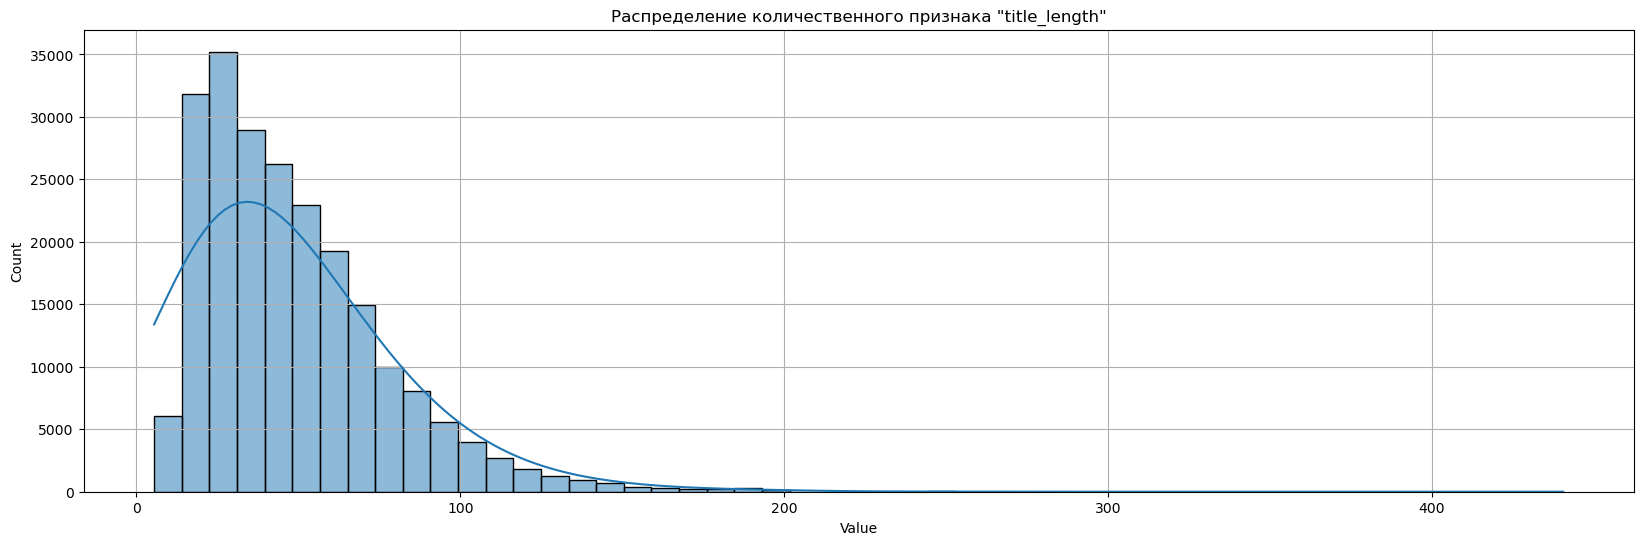

In [21]:
# Посмотрим на распределение длин названий
from pyspark.sql.functions import length

df_with_title_length = df.withColumn("title_length", length("Title"))
plot_quant_distribution(data=df_with_title_length, column="title_length", num_bins=50)

Проанализируем самые частые названия

Количество категорий признака Title: 212399


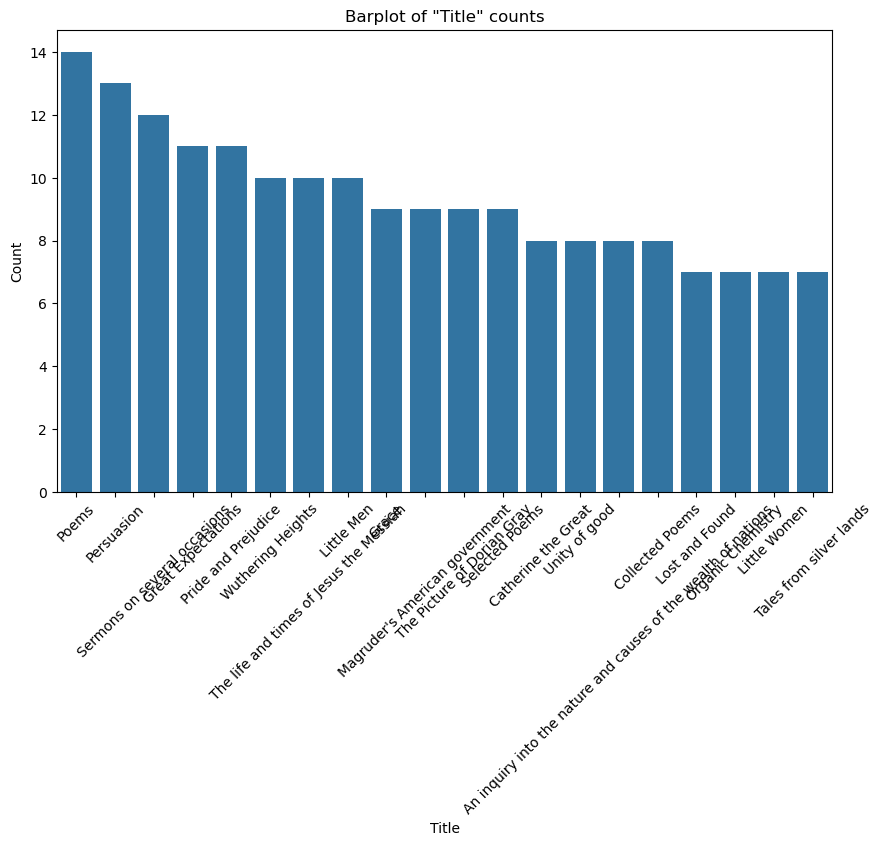

In [22]:
plot_cat_distribution(data=df, column_name="Title", top_n=20)

Проверим наличие дубликатов названий

In [23]:
print("Статистика по дубликатам названий:")
(
    df
    .groupBy("Title")
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .show(10, truncate=False)
)

Статистика по дубликатам названий:
+---------------------------------------+-----+
|Title                                  |count|
+---------------------------------------+-----+
|Poems                                  |14   |
|Persuasion                             |13   |
|Sermons on several occasions           |12   |
|Great Expectations                     |11   |
|Pride and Prejudice                    |11   |
|Little Men                             |10   |
|The life and times of Jesus the Messiah|10   |
|Wuthering Heights                      |10   |
|Grace                                  |9    |
|Magruder's American government         |9    |
+---------------------------------------+-----+
only showing top 10 rows



Посмотрим на примеры книг с одинаковыми названиями

In [24]:
duplicate_titles = (
    df
    .groupBy("Title")
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .limit(3)
)

for row in duplicate_titles.collect():
    title = row["Title"]
    print(f"\nКниги с названием: '{title}'")
    df.filter(col("Title") == title).select("Id", "authors", "publisher").show(truncate=False)


Книги с названием: 'Poems'
+----------+------------------------------------------+------------------------------------------------------------------------------------------------------+
|Id        |authors                                   |publisher                                                                                             |
+----------+------------------------------------------+------------------------------------------------------------------------------------------------------+
|B00086B820| published by the Houghton Mifflin Company|1904. Detailed contents. Alphabetical lists of titles and first lines. 80pp. 53/8 x 81/2. Paperbound."|
|091530645X| published by the Houghton Mifflin Company|1904. Detailed contents. Alphabetical lists of titles and first lines. 80pp. 53/8 x 81/2. Paperbound."|
|0915306433| published by the Houghton Mifflin Company|1904. Detailed contents. Alphabetical lists of titles and first lines. 80pp. 53/8 x 81/2. Paperbound."|
|1892616017| publi

In [25]:
# Анализ специальных символов в названиях
print("Названия с кавычками в начале:")
df.filter(col("Title").startswith('"')).select("Title").show(10, truncate=False)

print("Названия с HTML-символами:")
df.filter(col("Title").contains("&quot;") | col("Title").contains("&amp;")).select("Title").show(10, truncate=False)

Названия с кавычками в начале:
+--------------------------------------------------------------------------------------------------------------------+
|Title                                                                                                               |
+--------------------------------------------------------------------------------------------------------------------+
|"""The Best Mistake Ever and Other Stories"                                                                         |
|"Japan's ""International Youth"": The Emergence of a New Class of Schoolchildren (Clarendon Paperbacks)"            |
|"""Time Out"" Film Guide"                                                                                           |
|"Tetrarch: The ""Well of Echoes"" Quartet"                                                                          |
|"On the ""Lee Side"" of My Navy Life"                                                                               |
|"""I'm Not Cute!

In [26]:
# Статистика по названиям
print("Общая статистика по столбцу Title:")
print(f"Уникальных названий: {df.select('Title').distinct().count()}")
print(f"Всего записей: {df.count()}")
print(f"Процент уникальных названий: {100 * df.select('Title').distinct().count() / df.count():.2f}%")

Общая статистика по столбцу Title:
Уникальных названий: 212399
Всего записей: 221989
Процент уникальных названий: 95.68%


#### Анализ столбца `authors`

Данный столбец содержит информацию об авторах книг и представляет собой **категориальный признак**. Проанализируем распределение авторов и наличие пропущенных значений.

In [27]:
count_nulls(data=df, column_name="authors")

Число колонок с NULL: 32178 (14.50%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Проанализируем распределение авторов

Количество категорий признака authors: 133014


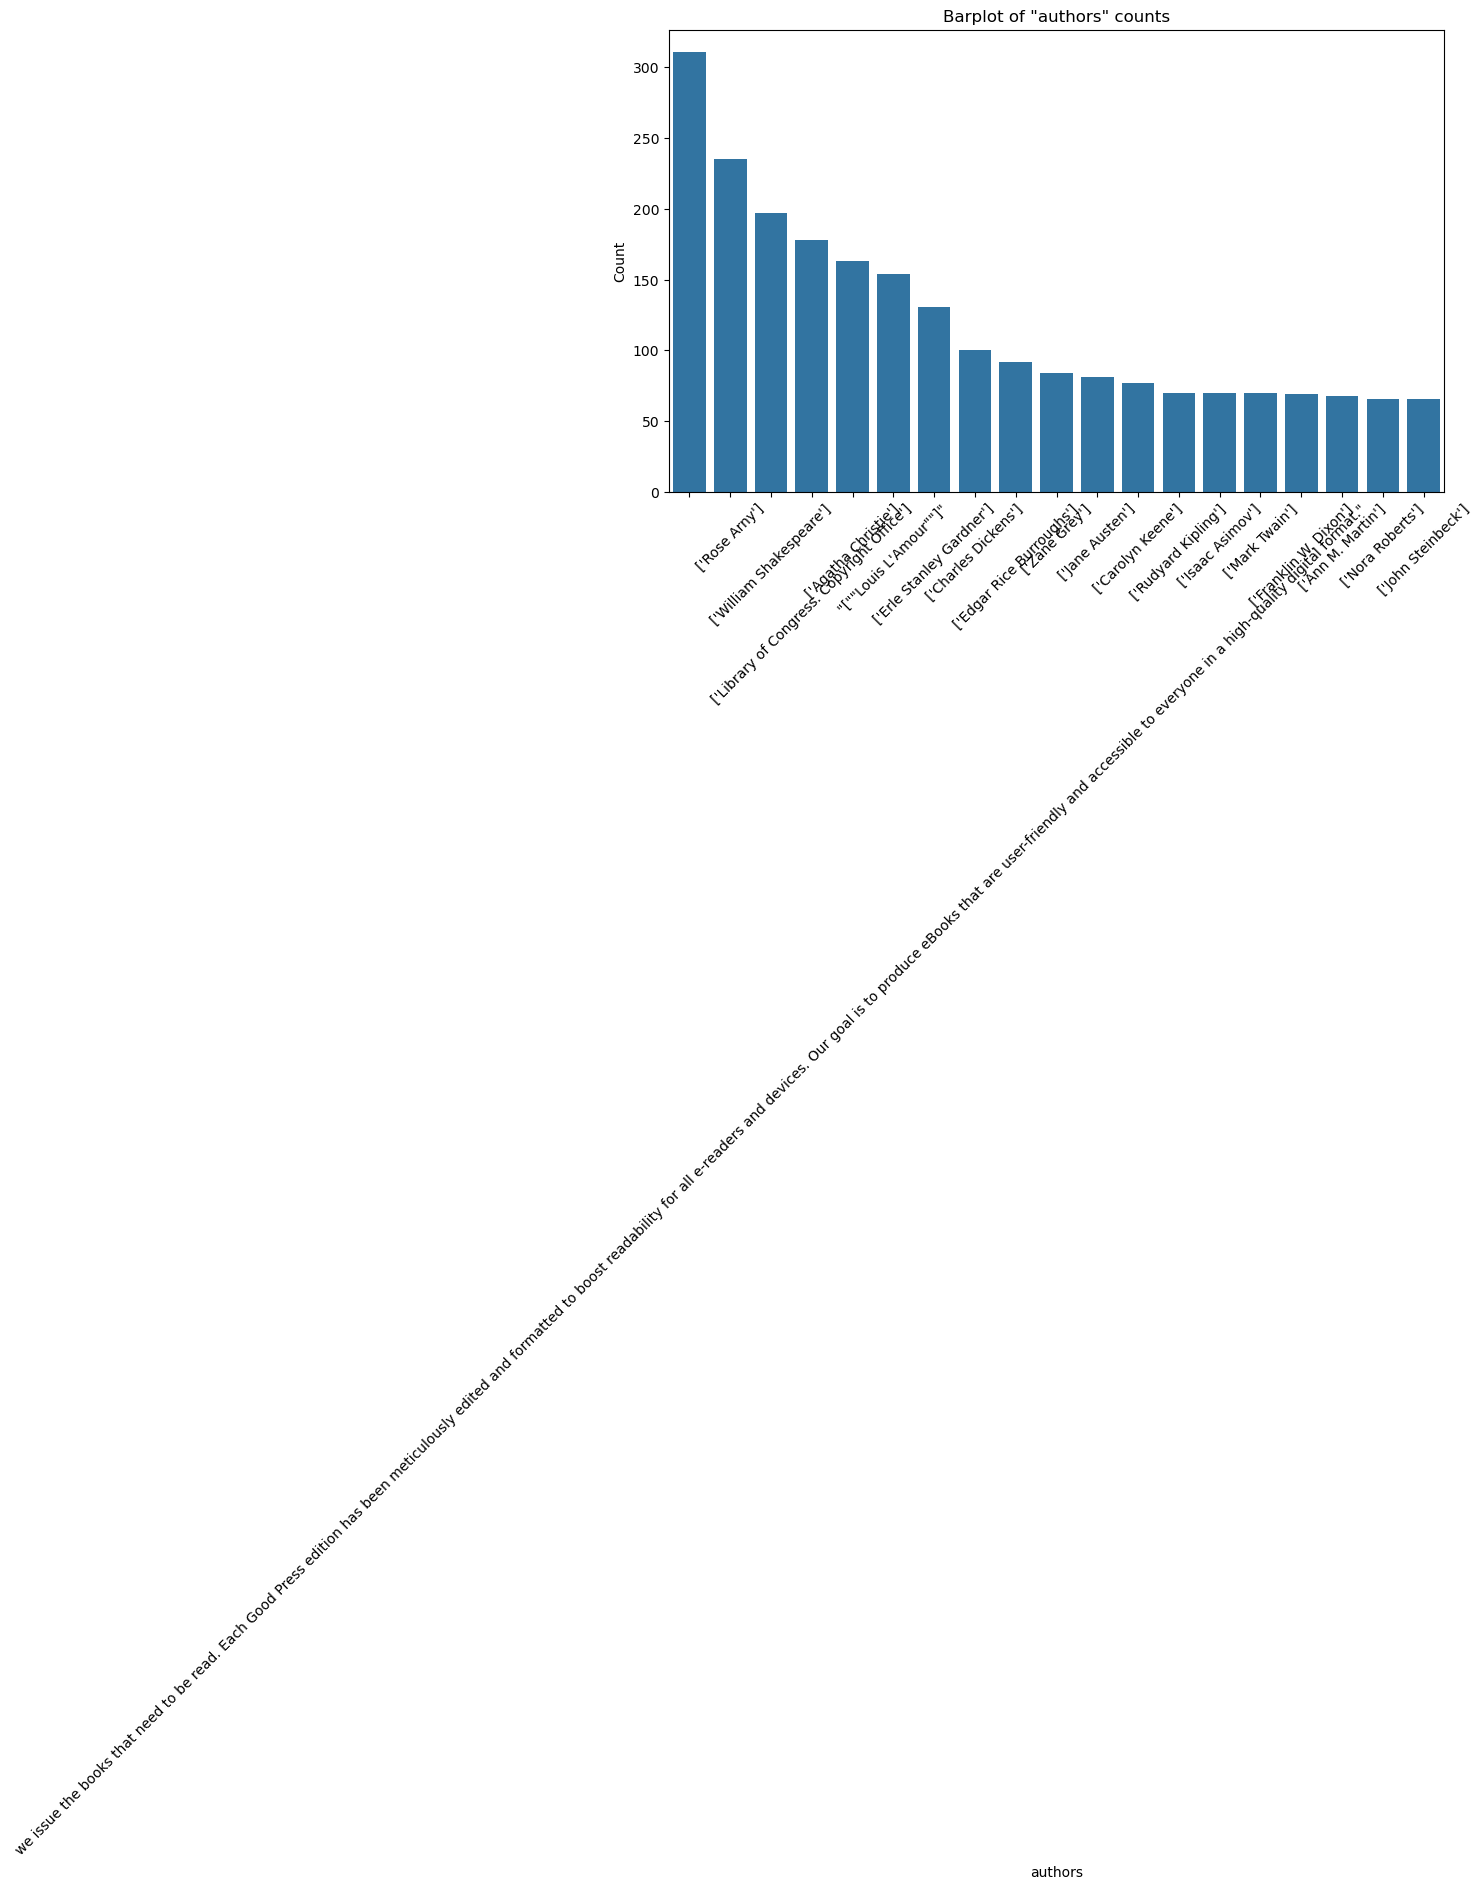

In [28]:
plot_cat_distribution(data=df, column_name="authors", top_n=20)

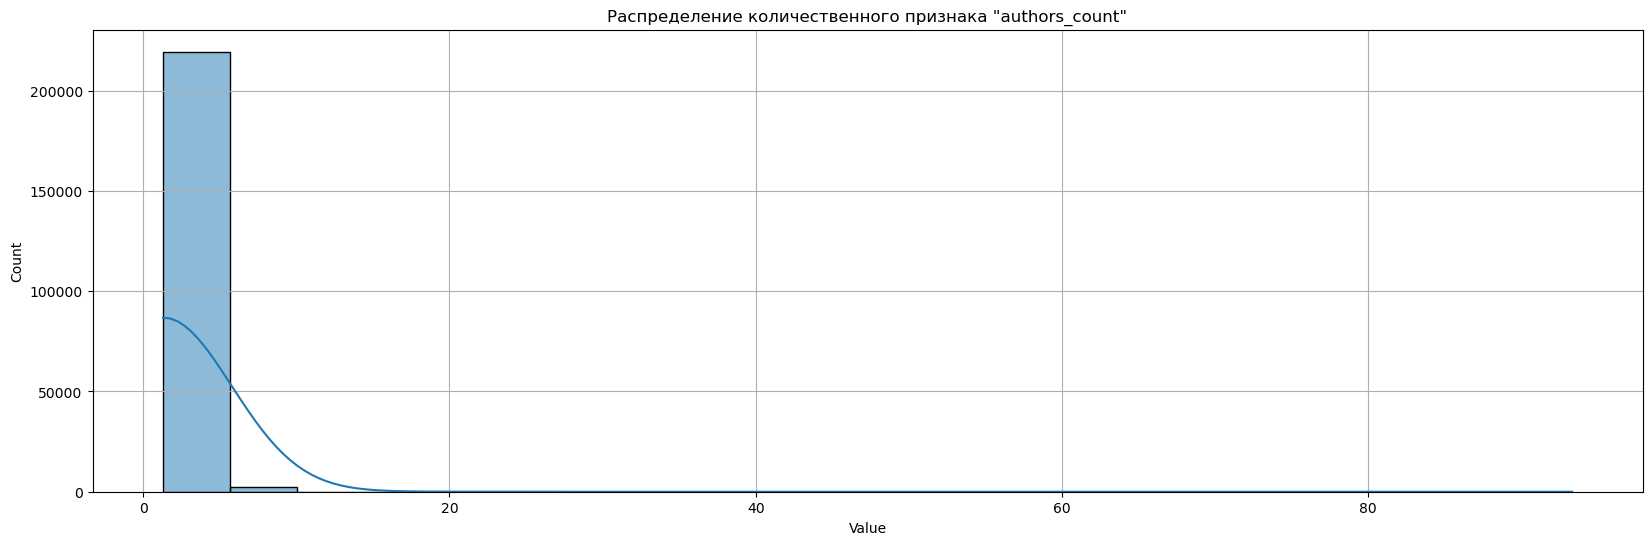

In [29]:
# Посмотрим на статистику по количеству авторов на книгу
from pyspark.sql.functions import split, size, stddev

df_with_authors_count = df.withColumn("authors_count", size(split(col("authors"), ",")))
plot_quant_distribution(data=df_with_authors_count, column="authors_count", num_bins=20)

Статистика по количеству авторов

In [31]:
print("Топ-15 авторов по количеству книг:")
(
    df
    .groupBy("authors")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(15, truncate=False)
)

Топ-15 авторов по количеству книг:
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+
|authors                                                                                                                                                                                                                                                                            |books_count|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+
|NULL                                                                                          

Проверим наличие книг без указания автора (NULL или пустые строки)

In [32]:
df.filter(col("authors").isNull() | (col("authors") == "") | (col("authors") == "[]")).count()

32178

#### Анализ столбца `publisher`

Данный столбец содержит информацию об издательствах книг и представляет собой **категориальный признак**. Проверим наличие пропущенных значений и проанализируем распределение издательств.

In [33]:
count_nulls(data=df, column_name="publisher")

Число колонок с NULL: 75945 (34.21%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Количество категорий признака publisher: 34246


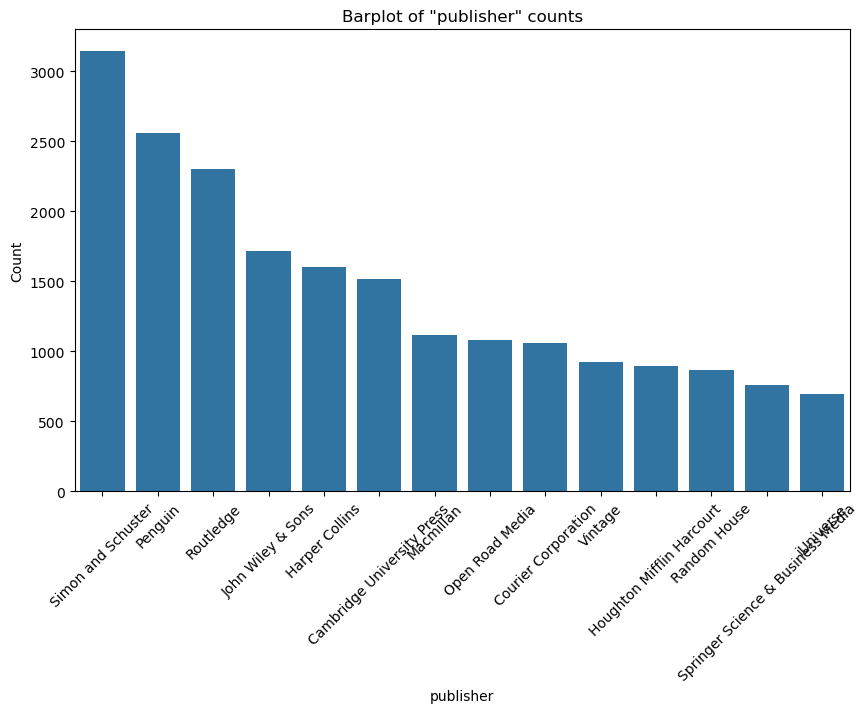

In [34]:
plot_cat_distribution(data=df, column_name="publisher", top_n=15)

In [35]:
print("Общая статистика по издательствам:")
print(f"Уникальных издательств: {df.select('publisher').distinct().count()}")
print(f"Количество записей с указанным издательством: {df.filter(col('publisher').isNotNull()).count()}")

Общая статистика по издательствам:
Уникальных издательств: 34246
Количество записей с указанным издательством: 146044


In [36]:
print("Топ-10 издательств по количеству книг:")
(
    df
    .groupBy("publisher")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(10, truncate=False)
)

Топ-10 издательств по количеству книг:
+--------------------------+-----------+
|publisher                 |books_count|
+--------------------------+-----------+
|NULL                      |75945      |
|Simon and Schuster        |3142       |
|Penguin                   |2560       |
|Routledge                 |2300       |
|John Wiley & Sons         |1716       |
|Harper Collins            |1606       |
|Cambridge University Press|1519       |
|Macmillan                 |1115       |
|Open Road Media           |1079       |
|Courier Corporation       |1059       |
+--------------------------+-----------+
only showing top 10 rows



#### Анализ столбца `publishedDate`

Данный столбец содержит даты публикации книг и представляет собой **временной признак**. Проанализируем распределение дат и наличие пропущенных значений.

In [39]:
count_nulls(data=df, column_name="publishedDate")

Число колонок с NULL: 26676 (12.02%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Посмотрим на различные форматы дат в данных

In [40]:
print("Примеры различных форматов дат:")
df.select("publishedDate").distinct().orderBy("publishedDate").show(20, truncate=False)

Примеры различных форматов дат:
+--------------------------------------------------------------------------------------------------------------------------+
|publishedDate                                                                                                             |
+--------------------------------------------------------------------------------------------------------------------------+
|NULL                                                                                                                      |
| "" ""Cruising for Prostitutes                                                                                            |
| "" accompanied by illustrations of various animals."                                                                     |
| "" and ""In the Old South."""                                                                                            |
| "" and ""Tawny                                                                             

Преобразуем даты в год публикации для анализа

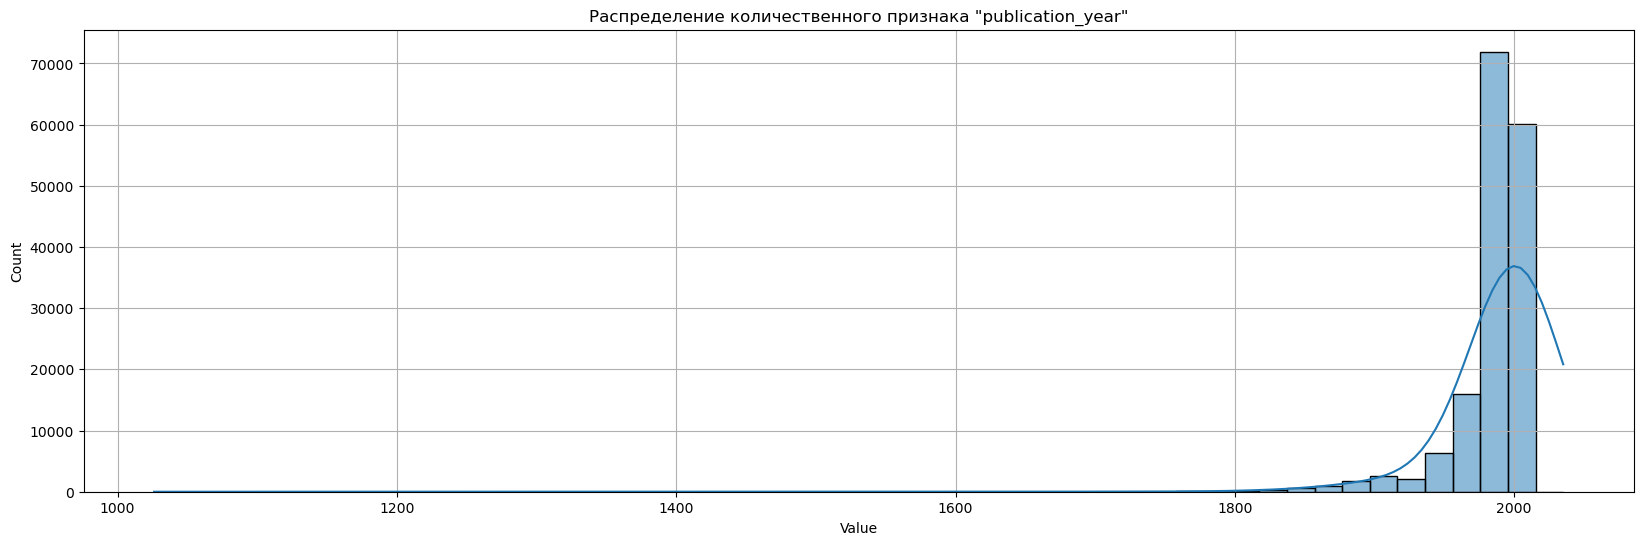

In [41]:
from pyspark.sql.functions import year, from_unixtime, to_date

# Извлекаем год из различных форматов дат
df_with_year = df.withColumn(
    "publication_year",
    when(col("publishedDate").rlike(r"^\d{4}$"), col("publishedDate").cast("int"))  # только год
    .when(col("publishedDate").rlike(r"^\d{4}-\d{2}-\d{2}$"), year(to_date(col("publishedDate"), "yyyy-MM-dd")))  # YYYY-MM-DD
    .when(col("publishedDate").rlike(r"^\d+$"), year(from_unixtime(col("publishedDate").cast("long"))))  # timestamp
    .otherwise(None)
)

# Анализ распределения годов публикации
plot_quant_distribution(data=df_with_year.filter(col("publication_year").isNotNull()), column="publication_year", num_bins=50)

Статистика по годам публикации

In [43]:
print("Топ-10 годов по количеству опубликованных книг:")
(
    df_with_year
    .filter(col("publication_year").isNotNull())
    .groupBy("publication_year")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(10, truncate=False)
)

Топ-10 годов по количеству опубликованных книг:
+----------------+-----------+
|publication_year|books_count|
+----------------+-----------+
|2004            |6559       |
|2003            |6407       |
|2002            |6214       |
|2005            |6210       |
|2000            |6099       |
|2001            |5767       |
|1999            |5638       |
|1998            |5148       |
|2012            |4812       |
|2013            |4518       |
+----------------+-----------+
only showing top 10 rows



#### Анализ столбца `categories`

Данный столбец содержит категории/жанры книг и представляет собой **категориальный признак**. Проанализируем распределение категорий и их влияние на рейтинги.

In [44]:
count_nulls(data=df, column_name="categories")

Число колонок с NULL: 42107 (18.97%)


Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Количество категорий признака categories: 28358


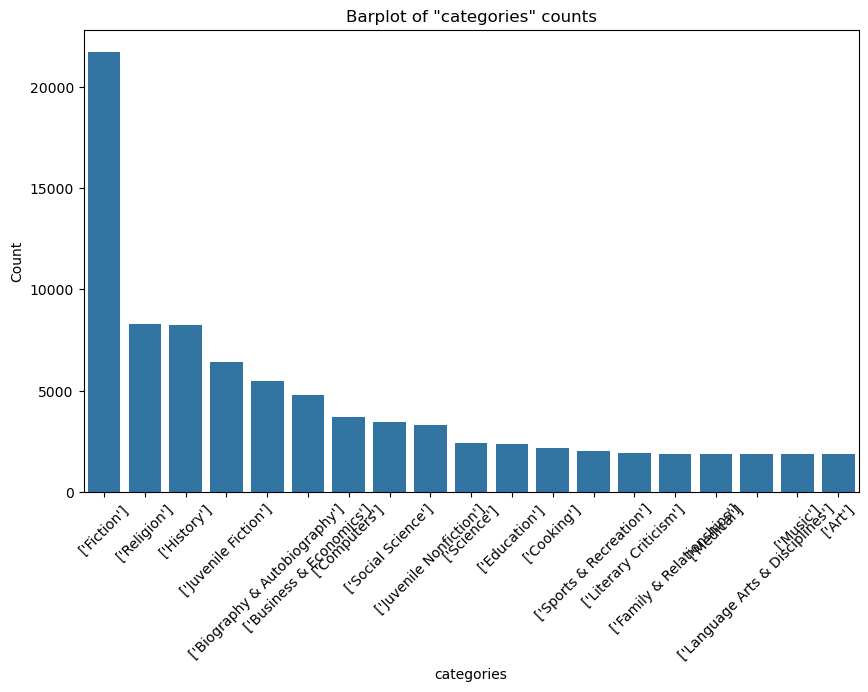

In [45]:
plot_cat_distribution(data=df, column_name="categories", top_n=20)

In [46]:
print("Примеры различных форматов категорий:")
df.select("categories").distinct().orderBy("categories").show(20, truncate=False)

Примеры различных форматов категорий:
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|categories                                                                                                                                                                                                                                                                                                                                                                                                                               

In [48]:
# Проверим категории с самыми противоречивыми отзывами (высокое стандартное отклонение)
print("Категории с самыми противоречивыми оценками:")
(
    df
    .filter(col("categories").isNotNull())
    .groupBy("categories")
    .agg(
        mean("review_score").alias("avg_rating"),
        count("Id").alias("books_count"),
        stddev("review_score").alias("rating_std")
    )
    .filter("books_count >= 20")  # только категории с 20+ книгами
    .orderBy("rating_std", ascending=False)
    .show(10, truncate=False)
)

Категории с самыми противоречивыми оценками:
+------------------------+------------------+-----------+------------------+
|categories              |avg_rating        |books_count|rating_std        |
+------------------------+------------------+-----------+------------------+
|['Sex']                 |3.1904761904761907|21         |1.7210185245675778|
|['Knowledge, Theory of']|3.5714285714285716|21         |1.6604646509766046|
|['Physics']             |3.903225806451613 |31         |1.640220284182939 |
|['Geology']             |3.5172413793103448|29         |1.6392657253253973|
|['Study Aids']          |3.562642369020501 |439        |1.6019589426698346|
|['Abortion']            |3.8181818181818183|22         |1.592732412176175 |
|['Evolution']           |4.1               |30         |1.5613875350094089|
|['Rome']                |3.71875           |32         |1.528954418190165 |
|['Ethnology']           |3.757575757575758 |33         |1.5213132285607522|
|['Engineering']         |4.05 

#### Анализ столбца `review_score`

Данный столбец содержит оценки книг пользователями и представляет собой **количественный признак**. Проанализируем распределение оценок и наличие пропущенных значений.

In [49]:
count_nulls(data=df, column_name="review_score")

Число колонок с NULL: 1710 (0.77%)


Минимальное значение:          1.00
Среднее значение:              11386.86
Среднеквадратичное отклонение: 3779645.70
Первый квартиль:               4.00
Медиана:                       5.00
Третий квартиль:               5.00
Максимальное значение:         1295568000.00


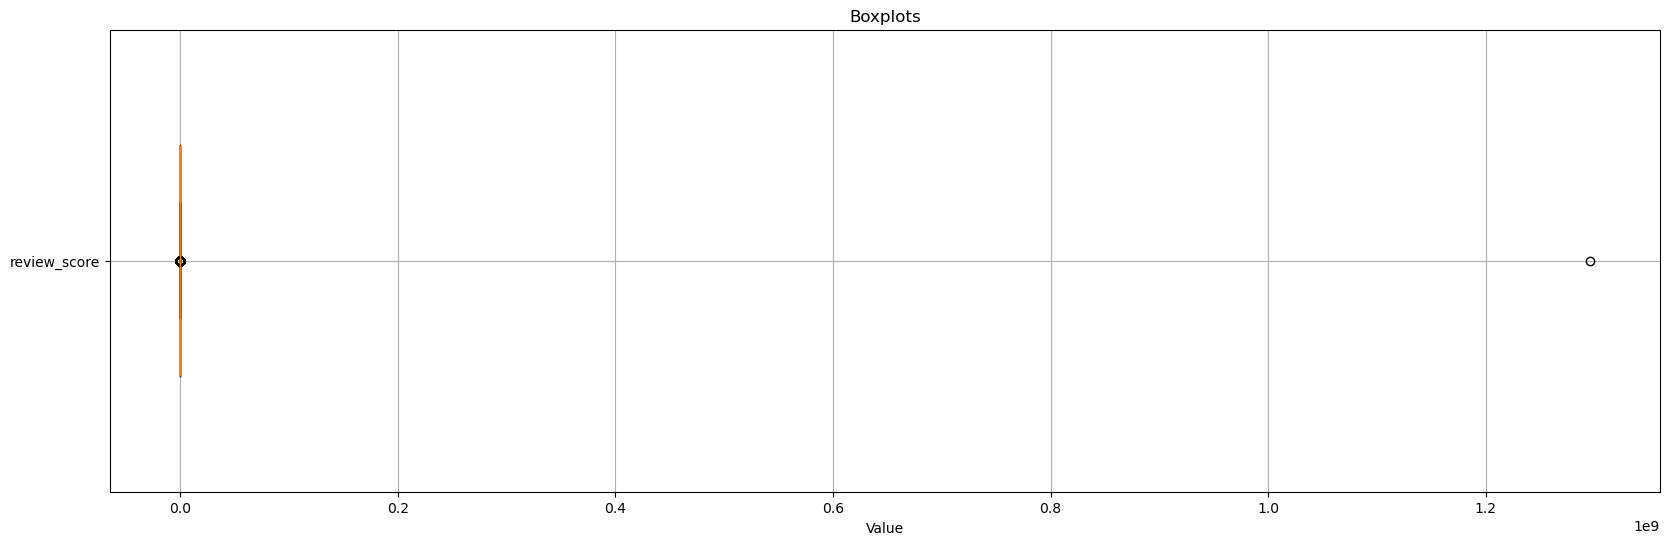

In [51]:
# Построим boxplot для визуализации выбросов
plot_boxplots(data=df, columns=["review_score"])

Сохраняет очищенную и обработанную таблицу на диск.

In [ ]:
df.write \
    .mode("overwrite") \
    .option("compression", "snappy") \
    .parquet("sobd_lab1_table_parquet")

print("Данные сохранены в sobd_lab1_table_parquet")

Останавливаем `Spark`-сессию.

In [ ]:
spark.stop()